In [ ]:
# pip install tldextract tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 2.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import json
import pathlib
from collections import defaultdict
import unicodedata
import html

import requests
from bs4 import BeautifulSoup
import tldextract
import pandas as pd

from datetime import datetime
from dateutil import parser as dateparser
from dateutil.parser import ParserError

import nltk
nltk.download('punkt')  # Correct token is 'punkt'
from nltk.tokenize import sent_tokenize

from google.colab import drive, userdata, files
from google.colab import auth
auth.authenticate_user()
drive.mount('/content/drive')

from google.cloud import bigquery
import google.generativeai as genai

import yfinance as yf
from tavily import TavilyClient


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mounted at /content/drive


In [ ]:
# === Config ===

COMPANY = "ISCO"
DATA_PATH = "/content/drive/MyDrive/isco_data"
os.makedirs(DATA_PATH, exist_ok=True)

GOOGLE_GENAI_KEY    = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key = GOOGLE_GENAI_KEY)
model = genai.GenerativeModel("gemini-1.5-flash")



# D1.1.1 SEC Filings Event Extraction Notebook

  This notebook processes SEC filings (e.g., 8-K, 10-K, 10-Q) for a specific company using the EDGAR API. It downloads the raw filing content, cleans and parses the text, and then uses a language model (LLM) to extract structured events related to clinical trials, corporate updates, regulatory announcements, or intellectual property (IP) disclosures. The extracted events are then compiled into a structured CSV file for further analysis or integration into a biotech event database.



In [ ]:
# === Config for D1.1.1 ===

CIK = "0001355790"  # ISCO
FORM_TYPES = ["8-K", "10-K", "10-Q"]
HEADERS = {"User-Agent": "boyangzhu03@gmail.com"}
BASE_URL = "https://www.sec.gov"


important_keywords = [
    "ind", "clinical trial", "fda", "phase", "partnership", "acquisition",
    "ipo", "series a", "series b", "pipe", "merger", "split", "delisting", "patent", "licensing"
]


In [ ]:
#fetches recent SEC filing URLs for a given CIK
def fetch_filing_urls(cik):
    try:
        index_url = f"https://data.sec.gov/submissions/CIK{cik}.json"
        response = requests.get(index_url, headers=HEADERS)
        response.raise_for_status()
        data = response.json()["filings"]["recent"]

        urls = []

        for i in range(len(data["form"])):
            if data["form"][i] in FORM_TYPES:
                accession = data["accessionNumber"][i].replace("-", "")
                primary_doc = data["primaryDocument"][i]
                if accession and primary_doc:
                    url = f"{BASE_URL}/Archives/edgar/data/{int(cik)}/{accession}/{primary_doc}"
                    urls.append((data["form"][i], data["filingDate"][i], url))
        return urls
    except Exception as e:
        print(f"[ERROR] Fetching filings: {e}")
        return []

def clean_text(text):
    text = html.unescape(text)
    text = unicodedata.normalize("NFKD", text)
    return re.sub(r"[\x80-\xFF]+", "", text)

In [ ]:
#Write description and category for each event given the scraped content
import google.generativeai as genai

def extract_events_llm(content, max_chars=12000):
    try:
        content = content[:max_chars]

        prompt = f"""
You are an expert analyst specializing in scientific and financial disclosures for biotech companies.


Your task is to extract major milestone events for a company (e.g., ISCO) from the SEC filing below.
These events should be time-indexed and support downstream tasks like bankruptcy prediction, asset valuation, and trial outcome forecasting.
Avoid repeating the same event with only slight variations. Combine related details into a single concise event.

Focus only on material events, specifically:

1. Therapy-specific R&D events
   - IND filings or approvals
   - Clinical trial initiations, interim results, completions
   - Regulatory feedback (e.g., FDA responses)

2. Corporate financial events
   - Venture rounds (e.g., Series A/B), PIPEs, IPOs
   - Mergers, acquisitions, partnerships, licensing
   - Stock splits, delistings, earnings releases

3. Intellectual property events
   - Patent applications, grants, licensing, or disputes

  Ignore routine administrative disclosures like:
- Board appointments, executive compensation
- Legal disclaimers or document formatting
- Shareholder meetings or procedural announcements

Format your answer in strict JSON, as:
[
  {{
    "description": "Concise summary of the event (1–2 sentences) Use company name as subject.",
    "subtype": "clinical" | "corporate" | "regulatory" | "ip"
  }},
  ...
]

Here is the filing content:
\"\"\"
{content[:max_chars]}
\"\"\"
"""

        response = model.generate_content(
            prompt,
            generation_config={"max_output_tokens": 1500}
        )
        reply = response.text.strip()

        # Attempt to find JSON-like content inside reply
        start = reply.find('[')
        end = reply.rfind(']') + 1
        if start == -1 or end == 0:
            raise ValueError("JSON structure not found in reply")

        json_part = reply[start:end]
        return json.loads(json_part)

    except Exception as e:
        print(f"[LLM ERROR] Failed to extract events: {e}")
        return []


In [ ]:

filing_urls = fetch_filing_urls(CIK)
print(f"[INFO] Found {len(filing_urls)} filings")

all_events = []
for form_type, filing_date, url in filing_urls:
    print(f"[INFO] Parsing {form_type} from {filing_date}")
    try:
        response = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")
        content = clean_text(soup.get_text(" ", strip=True))

        paragraphs = content.split("\n")
        relevant_paragraphs = [p for p in paragraphs if any(k in p.lower() for k in important_keywords)]

        if not relevant_paragraphs:
            print(f"[INFO] No relevant content in {filing_date}, skipping.")
            continue
        reduced_content = "\n".join(relevant_paragraphs)


        events = extract_events_llm(reduced_content)

        if not events:
            print(f"[INFO] No valid events extracted from {filing_date}, skipping.")
            continue  # Skip to next filing

        for e in events:
            all_events.append({
                "timestamp": filing_date,
                "form_type": form_type,
                "event_type": "sec_disclosure",
                "event_subtype": e.get("subtype", "unknown"),
                "description": e.get("description", ""),
                "source_url": url,
                "confidence": "N/A"
            })

    except Exception as e:
        print(f"[ERROR] Parsing filing: {e}")

In [ ]:
D1_df = pd.DataFrame(all_events)
output_path = os.path.join(DATA_PATH, "D1.1.1_SEC.csv")
D1_df.to_csv(output_path, index=False)
print(f"Saved {len(D1_df)} events to {output_path}")

# D1.1.2 – Extract and Normalize Clinical Trial Records

This section retrieves clinical trial data from ClinicalTrials.gov's v2 API for selected sponsor organizations. It handles pagination, extracts key metadata fields (e.g., NCT ID, brief title, status, start/completion dates), and normalizes date formats for consistency.

The cleaned and structured output is fed into a large language model (LLM) to generate event descriptions and extract milestone-relevant information.  
The final LLM-processed output is saved as a CSV file for downstream use in the ISCO event timeline database.

In [ ]:
#=== Config ===

SEARCH_TERMS = [
    "ISCO",
    "International Stem Cell Corporation",
    "Cyto Therapeutics Pty Limited",
    "Lifeline Cell Technology, LLC",
    "Lifeline Skin Care, Inc."
]


BASE_V2 = "https://clinicaltrials.gov/api/v2/studies"

In [ ]:
def fetch_all_trials_v2(sponsor_names, page_size=100):
    BASE_V2 = "https://clinicaltrials.gov/api/v2/studies"
    all_studies = []

    for sponsor in sponsor_names:
        print(f"🔍 Fetching trials for: {sponsor}")
        params = {
            "query.term": sponsor,
            "pageSize": page_size,
            "format": "json"
        }

        while True:
            response = requests.get(BASE_V2, params=params)
            try:
                response.raise_for_status()
                data = response.json()
            except Exception as e:
                print(f"[ERROR] Fetch error: {e}")
                break

            studies = data.get("studies", [])
            all_studies.extend(studies)

            token = data.get("nextPageToken")
            if not token:
                break
            params["pageToken"] = token

    print(f"Total studies fetched: {len(all_studies)}")
    return all_studies

In [ ]:

def flatten_study_json(study):
    if isinstance(study, list):
        study = study[0]
    elif "study" in study:
        study = study["study"]

    def get_nested(dct, path, default=""):
        for key in path:
            if isinstance(dct, dict):
                dct = dct.get(key, {})
            elif isinstance(dct, list) and isinstance(key, int):
                if 0 <= key < len(dct):
                    dct = dct[key]
                else:
                    return default
            else:
                return default
        return dct if isinstance(dct, str) else default

    protocol = study.get("protocolSection", {})
    ident = protocol.get("identificationModule", {})
    sponsor = protocol.get("sponsorCollaboratorsModule", {})
    status = protocol.get("statusModule", {})
    desc = protocol.get("descriptionModule", {})
    design = protocol.get("designModule", {})
    contact = protocol.get("contactsLocationsModule", {})

    def safe_parse_date(date_str):
        from dateutil.parser import parse
        if not date_str:
            return ""
        try:
            return parse(date_str).date().isoformat()  # returns YYYY-MM-DD
        except Exception:
            return ""

    return {
        "nct_id": ident.get("nctId", ""),
        "brief_title": ident.get("briefTitle", ""),
        "official_title": ident.get("officialTitle", ""),
        "lead_sponsor": sponsor.get("leadSponsor", {}).get("name", ""),
        "status": status.get("overallStatus", ""),
        "phase": design.get("phases", ["N/A"])[0].replace("PHASE", "Phase "),
        "start_date": (
            safe_parse_date(get_nested(status, ["startDateStruct", "date"])) or
            safe_parse_date(status.get("studyFirstSubmitDate")) or
            safe_parse_date(get_nested(status, ["studyFirstPostDateStruct", "date"]))
        ),
        "completion_date": safe_parse_date(get_nested(status, ["completionDateStruct", "date"])),
        "last_update_posted": safe_parse_date(get_nested(status, ["lastUpdatePostDateStruct", "date"])),
        "study_type": design.get("studyType", ""),
        "study_model": get_nested(design, ["designInfo", "designAllocation"]),
        "masking": get_nested(design, ["designInfo", "designMasking"]),
        "description": desc.get("briefSummary", "")
    }


In [ ]:
def extract_event_llm(study):
    try:
        # Extract metadata from pandas Series
        title = study.get("brief_title", "")
        sponsor = study.get("lead_sponsor", "")
        start_date = study.get("start_date", "")
        nct_id = study.get("nct_id", "")
        phase = study.get("phase", "")

        try:
            timestamp = datetime.fromisoformat(start_date).date().isoformat()   #parse_date(start_date).isoformat()
        except Exception:
            timestamp = ""

        # Prompt
        prompt = f"""
You are a biomedical analyst. Given the following clinical trial information, return a structured clinical event.

Trial Title: {title}
Sponsor: {sponsor}
Start Date: {start_date}

Return only a JSON object with:
- "subtype": trial phase (e.g., "Phase 2", "Phase I/II", or "N/A" if not available)
- "description": a 1–2 sentence plain English summary of the trial

Do not wrap it in markdown or code blocks. No "json" label.
"""

        response = model.generate_content(prompt)
        reply = response.text.strip()

        # Clean LLM response
        if reply.startswith("```"):
            reply = reply.split("```")[1].strip()
        if reply.lower().startswith("json"):
            reply = reply[len("json"):].strip()

        try:
            parsed = json.loads(reply)
        except json.JSONDecodeError:
            print(f"[LLM WARNING] Invalid JSON format:\n{reply}")
            parsed = {}

        # Use 'phase' from data if LLM subtype missing
        return {
            "timestamp": timestamp,
            "form_type": "clinical_trials",
            "event_type": "clinical",
            "event_subtype": phase or parsed.get("subtype", "N/A"),
            "description": parsed.get("description", ""),
            "source_url": f"https://clinicaltrials.gov/study/{nct_id}",
            "confidence": "N/A"
        }

    except Exception as e:
        print(f"[LLM ERROR] Skipping study: {e}")
        return None

In [ ]:
studies = fetch_all_trials_v2(SEARCH_TERMS)
flattened_studies = [flatten_study_json(study) for study in studies]

filtered_studies = [
    study for study in flattened_studies
    if study.get("lead_sponsor", "").strip().lower() in [s.lower() for s in SEARCH_TERMS]
]

print(f"Retrieved {len(filtered_studies)} trials out of {len(flattened_studies)} total")


studies = pd.DataFrame(filtered_studies)
print(f"Retrieved {len(studies)} trials")

events = []
for _, study in studies.iterrows():
    event = extract_event_llm(study)
    if event:
        events.append(event)

D2_df = pd.DataFrame(events)
output_path = os.path.join(DATA_PATH, "D1.1.2_Clinical_Trials.csv")
D2_df.to_csv(output_path, index=False)
print(f"Saved {len(D2_df)} events to {output_path}")

## D1_1_3_Patent_Lifecycle.ipynb

This notebook extracts, filters, and normalizes patent lifecycle event data for a target company using publication metadata. It parses raw timestamps into ISO 8601 date strings (`YYYY-MM-DD`) and prepares the data for integration into a time-indexed milestone database. The pipeline is designed for use in Google Colab and supports Google Cloud authentication.


In [ ]:
def safe_parse_date(ts) -> str:
    try:
        if ts is None or pd.isna(ts) or str(ts).strip() == "":
            return pd.NaT

        ts_str = str(ts).strip()

        if not ts_str or ts_str in {"0", "00000000"}:
            return pd.NaT


        # Handle 8-digit raw int dates like 20240919
        if ts_str.isdigit() and len(ts_str) == 8:
            return f"{ts_str[:4]}-{ts_str[4:6]}-{ts_str[6:]}"  # → '2024-09-19'
        \
        # Fallback to flexible parsing
        return dateparser.parse(ts_str).date().isoformat()
    except Exception as e:
        print(f"[WARN] Failed to parse: {ts} → {e}")
        return pd.NaT


In [ ]:
def fetch_patent_events(company: str,
                        project_id: str,
                        row_limit: int | None = None) -> pd.DataFrame:
    """
    Query Google BigQuery patents table, flatten assignee array,
    filter by company substring (case-insensitive),
    and return a DataFrame already shaped for the event timeline.
    """

    client      = bigquery.Client(project=project_id)
    company_lc  = company.lower()

    sql = f"""
    SELECT
      publication_number AS patent_id,
      publication_date   AS raw_date,
      (SELECT txt.text FROM UNNEST(title_localized) txt
                        WHERE txt.language = 'en' LIMIT 1) AS title_en,
      (SELECT ab.text  FROM UNNEST(abstract_localized) ab
                        WHERE ab.language = 'en' LIMIT 1) AS abstract_en,
      ah.name AS assignee,
      CONCAT('https://patents.google.com/patent/', publication_number) AS source_url
    FROM  `patents-public-data.patents.publications`,
          UNNEST(assignee_harmonized) AS ah
    WHERE LOWER(ah.name) LIKE '%{company_lc}%'
    {f'LIMIT {row_limit}' if row_limit else ''}
    """

    df = client.query(sql).to_dataframe(bqstorage_client=None)   # stream → pd

    # ─ post-processing ──────────────────────────────────────────
    df["timestamp"]         = df["raw_date"].apply(safe_parse_date)
    df["event_type"]        = "patent_publication"
    df["description"] = df["title_en"].fillna("(no title)")
    df["confidence"]  = "N/A"
    df["form_type"]         = "patent"
    df["event_subtype"]     = "grant"

    cols = ["timestamp", "event_type", "event_subtype",
            "description", "patent_id", "source_url",
            "confidence", "assignee"]
    return (df[cols]
            .drop_duplicates(subset="patent_id")
            .sort_values("timestamp", ascending=False)
            .reset_index(drop=True))

In [ ]:
PROJECT_ID  = userdata.get('GOOGLE_PATENTID')
MAX_ROWS    = None

D3_df = fetch_patent_events(COMPANY, PROJECT_ID, MAX_ROWS)
D3_df = D3_df[D3_df['assignee'].str.lower().str.strip() == COMPANY.lower()]

output_path = os.path.join(DATA_PATH, "D1.1.3_Patent.csv")
D3_df.to_csv(output_path, index=False)
print(f"Saved {len(D3_df)} events to {output_path}")


##  D1.1.4 – Venture Funding and IPO Extraction

This notebook identifies and extracts venture funding, IPO, and acquisition-related events for a target biotech company using news and web search APIs. It leverages the Tavily API to retrieve relevant news articles and applies a large language model (LLM) to summarize and classify significant financial events. The output is structured for integration into the ISCO event timeline database.

Key steps:
- Query funding and IPO-related news using the Tavily API
- Use Gemini LLM to extract event type and description
- Standardize timestamps and save structured output as a CSV


In [ ]:
TAVILY_API_KEY      = userdata.get('TAVILY_API_KEY')
tavily = TavilyClient(api_key=TAVILY_API_KEY)

In [ ]:
TRUSTED_SOURCES = [
    "finance.yahoo.com",          # IPO calendar & news :contentReference[oaicite:1]{index=1}
    "nasdaq.com",                 # IPO tracking & pricing :contentReference[oaicite:2]{index=2}
    "marketwatch.com",            # IPO calendar & alerts
    "renaissancecapital.com",     # Daily IPO coverage & recaps :contentReference[oaicite:3]{index=3}
    "iposcoop.com",               # IPO data & performance metrics :contentReference[oaicite:4]{index=4}
    "seekingalpha.com",           # IPO news & analysis :contentReference[oaicite:5]{index=5}
    "stockanalysis.com",          # IPO news feed :contentReference[oaicite:6]{index=6}
    "news.crunchbase.com",        # Startup & VC funding updates
    "techcrunch.com",             # Funding rounds and IPO announcements
    "businesswire.com",           # Official press releases
    "globenewswire.com",          # Official press releases
    "prnewswire.com",             # Official press releases
    "sec.gov"                     # Regulatory filings/IPO registration data
]


BLOCKED_SOURCES = [
    "stocktitan.net",  # marketing-type blitz, low relevance
    "tipranks.com",    # aggregated market chatter
    "vbdata.cn",       # regional business database unrelated to IPO
]

In [ ]:
def fetch_html(url):
    try:
        return tavily.extract(url).get("raw_content", "")
    except Exception:
        return ""

USD_RE   = re.compile(r"\$?\s*([\d,.]+)\s*(million|billion|bn|m|k)?", re.I)
ROUND_RE = re.compile(r"(Series\s+[A-H]|Seed|PIPE|Bridge|IPO)", re.I)



def parse_series(text: str, company: str) -> str:
    """
    Extracts funding round only if the sentence contains the company name.
    """
    text = text.lower()
    company = company.lower()

    # Break the text into sentences
    sentences = sent_tokenize(text)

    for sent in sentences:
        if company in sent:
            match = ROUND_RE.search(sent)
            if match:
                return match.group(1).title()

    return "Unknown"

In [ ]:
def llm_description(article_text):
    prompt = (
        f"You are summarizing funding and IPO news for the company {COMPANY}.\n\n"
        "Write a one-sentence summary (≤25 words) of the funding or IPO event specifically involving this company. "
        "Include round (e.g., Series A), amount (in $M or $B), and lead investor if mentioned. "
        "If the content is not about a funding/IPO event related to the company, respond with: NOT FUNDING-RELATED.\n\n"
        "Content:\n"
        f"{article_text[:4000]}"
    )

    try:
        resp = model.generate_content(prompt)
        out  = getattr(resp, "text", "").strip()
        return out or None
    except Exception:
        return None

In [ ]:
base_l  = COMPANY.lower()
slug    = base_l.replace(" ", "-")


def tavily_search(
    query: str,
    max_results: int = 20,
    *,
    depth: str = "advanced",  # optional, can downgrade to "basic" if needed
    topic: str = "finance",
    include_domains: list[str] = None,
    exclude_domains: list[str] = None,
    retry_wait: int = 60,
    **kwargs,
) -> list[dict]:
    """
    Tavily search wrapper with sensible defaults for free-tier users.
    - Filters trusted sources
    - Uses finance topic
    - Auto-retries on rate limiting
    """
    while True:
        try:
            return tavily.search(
                query=query,
                max_results=max_results,
                search_depth=depth,
                include_domains=include_domains,
                exclude_domains=exclude_domains,
                topic=topic,
                include_raw_content=False,
                **kwargs
            )["results"]
        except Exception as e:
            if "429" in str(e) or "UsageLimitExceededError" in str(e):
                print(f"Rate limit hit — sleeping {retry_wait}s...")
                time.sleep(retry_wait)
                continue
            raise



queries = [
    f'"{COMPANY}" raises $',
    f'"{COMPANY}" venture funding $',
    f'"{COMPANY}" "Series A" $',
    f'"{COMPANY}" "Series B" $',
    f'"{COMPANY}" IPO price $',
    f'"{COMPANY}" private placement $',
    f'"{COMPANY}" PIPE financing $'
]



In [ ]:
def extract_event_date_with_llm(article_text: str) -> str | None:
    """
    Extracts a structured date from the full article text using Gemini.
    Returns a YYYY-MM-DD string if successful, or None.
    """
    prompt = (
        f"Extract the date when the funding or IPO event of {COMPANY} occurred. "
        "Return only the date in YYYY-MM-DD format. "
        "If no valid date is found, return nothing.\n\n"
        + article_text[:4000]
    )

    try:
        response = model.generate_content(prompt)
        output = response.text.strip()

        if re.match(r"\d{4}-\d{2}-\d{2}", output):
            return output
    except Exception as e:
        print("⚠️ LLM date extraction failed:", e)

    return None

In [ ]:
def safe_parse_date(text, fallback=None):
    """Return YYYY-MM-DD or None."""
    try:
        d = dateparser.parse(text, fuzzy=True)
        return d.date().isoformat()
    except (ParserError, ValueError, OverflowError):
        return fallback

In [ ]:
import nltk
nltk.download('punkt_tab')

In [ ]:
events = []
seen = set()

for q in queries:
    hits = tavily_search(
        query=q,
        include_domains=TRUSTED_SOURCES,
        exclude_domains=BLOCKED_SOURCES
    )
    print(f"{q} → {len(hits)} hits")
    time.sleep(10)

    for h in hits:
        url = h["url"].lower()
        if url in seen:
            continue

        title = h["title"].lower()
        body  = h.get("content", "").lower()

        # Check relevance and fetch full text
        if base_l in title:
            text = fetch_html(url)
        else:
            if base_l not in body:
                full = fetch_html(url)
                if not full or base_l not in full.lower():
                    continue
                text = full
            else:
                text = body

        seen.add(url)

        # extract timestamp ------------------------------------
        pub_raw = h.get("published_date") or h.get("published")

        ts = extract_event_date_with_llm(text)
        if not ts:
            ts = safe_parse_date(text)

        if not ts or (ts.startswith("0") or ts.startswith("1") and len(ts.split("-")[0]) < 4):
            continue

        # Extract series & summary -----------------------------------
        series = parse_series(text, COMPANY)
        summary = llm_description(text)

        if not summary or summary.isspace():
            print("  Empty summary for:", url)
            print("   title  ->", h.get("title"))
            print("   body   ->", body[:120], "...")
            print("   text   ->", text[:120], "...")

        events.append({
            "timestamp": ts,
            "event_type": "ipo" if "ipo" in series.lower() else "venture_round",
            "description": summary,
            "source_url": h["url"],
            "confidence": "NA"
        })

print(f"Collected raw events: {len(events)}")

In [ ]:
D4_df = pd.DataFrame(events)[[
    "timestamp",
    "event_type",
    "description",
    "source_url",
    "confidence"
]]

D4_df = D4_df[D4_df["description"].str.strip()!= "NOT FUNDING-RELATED"]

output_path = os.path.join(DATA_PATH, "D1.1.4_Venture_Funding.csv")
D4_df.to_csv(output_path, index=False)
print(f"Saved {len(D4_df)} events to {output_path}")

## D1.1.5 – Stock Price Timeline for ISCO

This notebook fetches and stores the daily historical stock prices for **International Stem Cell Corporation (ISCO)** using the `yfinance` API. The retrieved data includes daily open, high, low, close, volume, and adjusted close prices.

Key steps:
- Use `yfinance.Ticker("ISCO")` to retrieve full historical daily stock data
- Reset the index to expose the date column
- Save the structured time series to `isco_stock_daily.csv` for downstream integration into the ISCO milestone database


In [ ]:
# Fetch daily stock data for ISCO
isco = yf.Ticker("ISCO")
hist = isco.history(period="max", interval="1d")

# Reset index to make 'Date' a column
hist.reset_index(inplace=True)

D5_df = pd.DataFrame(hist)
output_path = os.path.join(DATA_PATH, "D1.1.5_Stock.csv")
D5_df.to_csv(output_path, index=False)
print(f"Saved {len(D5_df)} events to {output_path}")

In [ ]:
D1_df = pd.read_csv('/content/drive/My Drive/isco_data/D1.1.1_SEC.csv')
D2_df = pd.read_csv('/content/drive/My Drive/isco_data/D1.1.2_Clinical_Trials.csv')
D3_df = pd.read_csv('/content/drive/My Drive/isco_data/D1.1.3_Patent.csv')
D4_df = pd.read_csv('/content/drive/My Drive/isco_data/D1.1.4_Venture_Funding.csv')

In [ ]:
# List of required columns to enforce consistency
required_cols = [
    "timestamp", "event_type",
    "description", "source_url", "confidence"
]

D1_df = D1_df[required_cols]
D2_df = D2_df[required_cols]
D3_df = D3_df[required_cols]
D4_df = D4_df[required_cols]

timeline_df = pd.concat([D1_df, D2_df, D3_df, D4_df], ignore_index=True)

# Sort by timestamp
timeline_df = timeline_df.sort_values("timestamp").reset_index(drop=True)

output_path = os.path.join(DATA_PATH, "D1_To_D4_Combined_Timeline.csv")
timeline_df.to_csv(output_path, index=False)
print(f"Combined D1–D4: {len(timeline_df)} events saved to {output_path}")


In [ ]:
events_df = pd.read_csv('/content/drive/My Drive/isco_data/D1_To_D4_Combined_Timeline.csv')

mask = events_df['timestamp'].str.match(r'^\d{4}-\d{2}-\d{2}$')
invalid = mask[~mask]
print("Number of rows not matching YYYY-MM-DD format:")
print(len(invalid))


stock_df = pd.read_csv('/content/drive/My Drive/isco_data/D1.1.5_Stock.csv')


In [ ]:
from datetime import timedelta


def compute_event_aligned_stock_metrics(events_df, stock_df):
    # --- Ensure both dataframes use timezone-naive, normalized datetime64 ---
    stock_df["Date"] = pd.to_datetime(stock_df["Date"], utc=True, errors='coerce') \
                            .dt.tz_convert(None).dt.normalize()
    stock_df.set_index("Date", inplace=True)

    events_df["timestamp"] = pd.to_datetime(events_df["timestamp"], errors='coerce') \
                                   .dt.normalize()

    results = []

    for _, row in events_df.iterrows():
        event_date = row["timestamp"]
        if pd.isna(event_date):
          continue

        def get_close(offset):
            target_date = event_date + timedelta(days=offset)
            try:
                # Get latest available stock price on or before target_date
                return stock_df.loc[target_date]["Close"]
            except:
                return None

        def get_vol(start_offset, end_offset):
            start = event_date + timedelta(days=start_offset)
            end = event_date + timedelta(days=end_offset)
            try:
                window = stock_df.loc[start:end]["Close"]
                return window.std() if not window.empty else None
            except:
                return None

        # Close prices around event
        close_0    = get_close(0)
        close_3d   = get_close(3)
        close_7d   = get_close(7)
        close_30d  = get_close(30)
        close_m3d  = get_close(-3)
        close_m7d  = get_close(-7)
        close_m30d = get_close(-30)

        # Returns (as percentages)
        return_3d   = (close_3d - close_0) / close_0 if close_0 and close_3d else None
        return_7d   = (close_7d - close_0) / close_0 if close_0 and close_7d else None
        return_30d  = (close_30d - close_0) / close_0 if close_0 and close_30d else None

        # Volatility
        vol_3d   = get_vol(-3, 3)
        vol_30d  = get_vol(-30, 30)

        results.append({
            "timestamp": event_date.strftime("%Y-%m-%d"),  # Optional: keep clean date format
            "event_type": row.get("event_type"),
            "event_description": row.get("description"),
            "source": row.get("source_url") or row.get("source"),
            "confidence_score": row.get("confidence_score"),
            "close_-30d": round(close_m30d, 2) if close_m30d is not None else None,
            "close_-7d":  round(close_m7d, 2)  if close_m7d is not None else None,
            "close_-3d":  round(close_m3d, 2)  if close_m3d is not None else None,
            "close_0d":   round(close_0, 2)    if close_0 is not None else None,
            "close_+3d":  round(close_3d, 2)   if close_3d is not None else None,
            "close_+7d":  round(close_7d, 2)   if close_7d is not None else None,
            "close_+30d": round(close_30d, 2)  if close_30d is not None else None,
            "return_+3d": round(return_3d, 2)  if return_3d is not None else None,
            "return_+7d": round(return_7d, 2)  if return_7d is not None else None,
            "return_+30d": round(return_30d, 2) if return_30d is not None else None,
            "volatility_±3d": round(vol_3d, 2)  if vol_3d is not None else None,
            "volatility_±30d": round(vol_30d, 2) if vol_30d is not None else None
        })

    return pd.DataFrame(results)

In [ ]:
Calculated_df = compute_event_aligned_stock_metrics(events_df, stock_df)
output_path = os.path.join(DATA_PATH, "Calculated_df.csv")
Calculated_df.to_csv(output_path, index=False)

In [ ]:
Calculated_df.head()

In [ ]:
# import pandas as pd
# import pyarrow as pa
# import pyarrow.parquet as pq


# #Convert to Pyarrow table

# df = pd.read_csv('/content/drive/My Drive/isco_data/Calculated_df.csv')
# df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
# arrow_table = pa.Table.from_pandas(df)

# print(arrow_table.schema)
# pq.write_table(arrow_table, '/content/drive/My Drive/isco_data/unified_events.parquet')


# Visualization

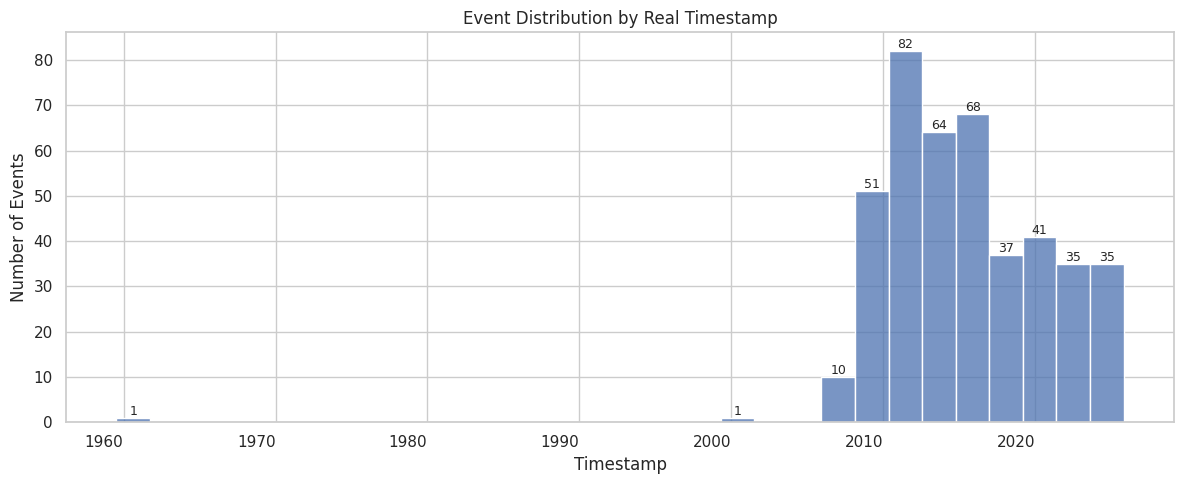

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/drive/My Drive/isco_data/Calculated_df.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df = df.sort_values('timestamp')
sns.set(style="whitegrid")

# Plot real datetime distribution using histogram (hour/min precision visible if range is small)
plt.figure(figsize=(12, 5))
hist_plot = sns.histplot(data=df, x='timestamp', bins=30, kde=False)

for patch in hist_plot.patches:
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width() / 2,
                 height,
                 f'{int(height)}',
                 ha='center',
                 va='bottom',
                 fontsize=9)


plt.title('Event Distribution by Real Timestamp')
plt.xlabel('Timestamp')
plt.ylabel('Number of Events')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()


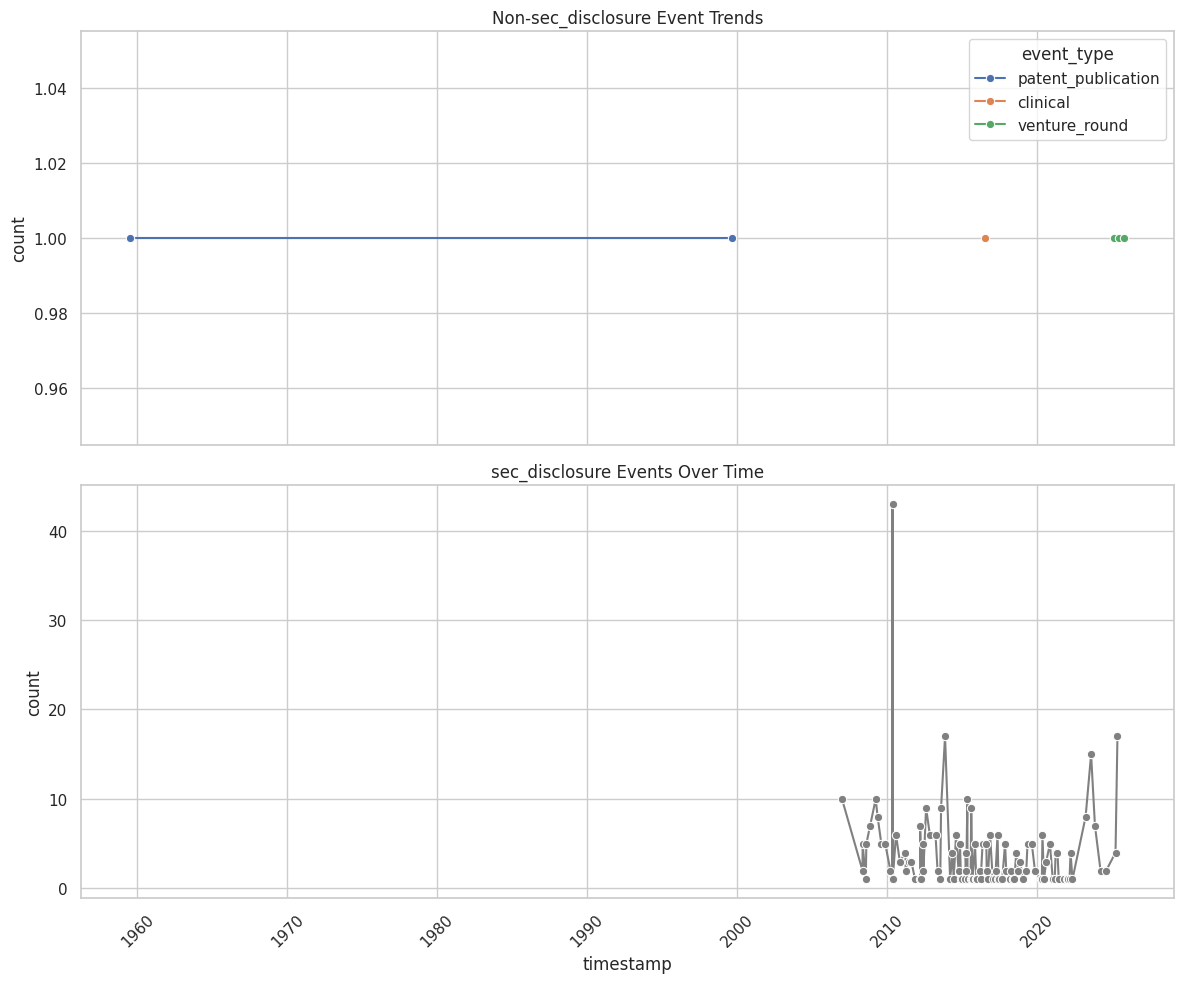

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot minor event types
minor_df = df[df['event_type'] != 'sec_disclosure']
event_trend_minor = minor_df.groupby([minor_df['timestamp'].dt.date, 'event_type']).size().reset_index(name='count')
sns.lineplot(data=event_trend_minor, x='timestamp', y='count', hue='event_type', marker='o', ax=ax1)
ax1.set_title("Non-sec_disclosure Event Trends")

# Plot sec_disclosure only
sec_df = df[df['event_type'] == 'sec_disclosure']
event_trend_sec = sec_df.groupby(sec_df['timestamp'].dt.date).size().reset_index(name='count')
sns.lineplot(data=event_trend_sec, x='timestamp', y='count', marker='o', ax=ax2, color='gray')
ax2.set_title("sec_disclosure Events Over Time")

plt.xticks(rotation=45)
plt.tight_layout()


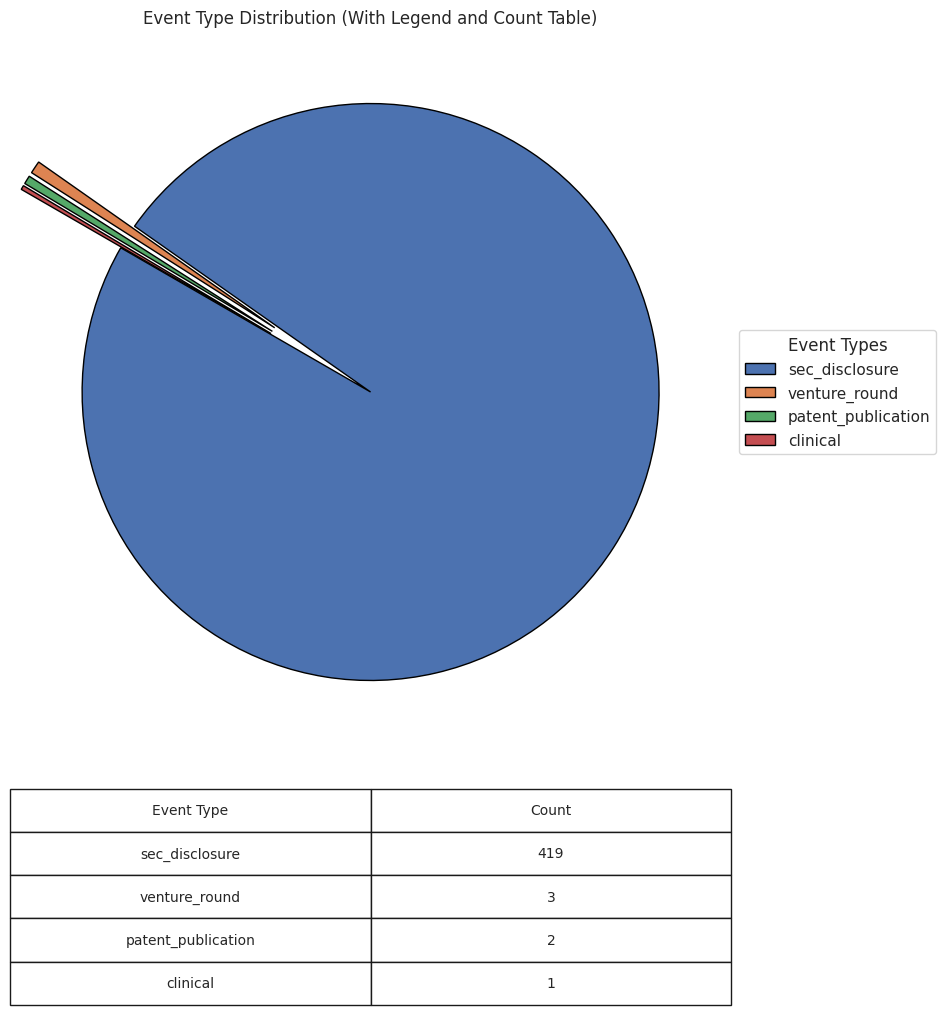

In [ ]:
counts = df['event_type'].value_counts()
labels = counts.index.tolist()
sizes = counts.values.tolist()

# Explode small slices
explode = [0 if i == 0 else 0.4 for i in range(len(sizes))]

fig, ax = plt.subplots(figsize=(10, 10))
wedges, _ = ax.pie(
    sizes,
    labels=[''] * len(labels),     # hide labels to prevent overlap
    explode=explode,
    startangle=150,
    wedgeprops={'edgecolor': 'black'}
)

# Add legend
ax.legend(wedges, labels, title="Event Types", loc="center left", bbox_to_anchor=(1.0, 0.5))

# Add count table
table_data = [[label, f"{count:,}"] for label, count in zip(labels, sizes)]
table = plt.table(cellText=table_data,
                  colLabels=["Event Type", "Count"],
                  cellLoc='center',
                  loc='bottom',
                  bbox=[0.0, -0.35, 1, 0.3])  # adjust table position

table.auto_set_font_size(False)
table.set_fontsize(10)

# Set title and layout
plt.title("Event Type Distribution (With Legend and Count Table)")
plt.subplots_adjust(bottom=0.25)  # make room for table
plt.tight_layout()
plt.savefig("event_type_distribution_legend_table.png")
plt.show()

In [ ]:
#Filter out invalid time stamp
df = pd.read_csv('/content/drive/My Drive/isco_data/Calculated_df.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')  # ensure datetime
df = df[df['timestamp'] >= pd.Timestamp('2001-01-01')]
df.head()